# Notebook E - Regional Fairness Across Algorithms

At a fixed operating point (d, R, behaviour), do preference-driven algorithms
create spatial inequity - systematically disadvantaging some regions? This loads
the per-request regional cache for every algorithm and compares them side-by-side.

Heaviest data load in the set, but it reads the pickle cache (one representative
run per algorithm at the target point), so it is fast after the first parse.

Only the median-d (258) run is cached per (R, behaviour, ic), so TARGET_D is fixed
to 258. Re-run with TARGET_R = 1.0 for the supply-scarce regime.

In [2]:
from pathlib import Path

GEOMETRY = 'imbalanced'          # 'balanced' or 'imbalanced'
TARGET_R = 0.5
TARGET_D = 258                 # median fleet size (only value cached for regional)
TARGET_BEHAVIOUR = 'go_back'
TARGET_IC = 'home'
EXPERIMENTS = ['exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6', 'exp7']

# Regions with fewer than MIN_REQUESTS origin requests are statistically
# meaningless (in the imbalanced layout the far-corner transition strips get a
# handful of requests and, under the safety-objective algorithms, zero pickups ->
# NaN safety -> a gray "NA" box). They are hidden from the Section 2 grid. A region
# with many requests but a NaN metric is kept - that absence is a real finding.
MIN_REQUESTS = 20

CACHE_DIR = Path('.') / 'cache'

In [3]:
import sys
import pickle
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from exp_utils import (GROUP_CONFIGS, load_regions, aggregate_region_stats,
                       compute_regional_gini, plot_region_heatmap, fmt_display,
                       exp_label, apply_pub_style, METRIC_RANGE, legend_outside)

apply_pub_style()

## 1. Find and load the matching run for each algorithm

For each experiment, open its regional cache and select the representative run at
(R, behaviour, ic). Report which algorithms were found.

In [4]:
# (column in aggregate_region_stats, source request column, label, cmap, higher_is_better)
# service_rate = done/total = 1 - non_completion_rate (derived below), the exact
# per-region definition used by REGIONAL_SAFETY_SIGNIFICANCE.md (region_service_req_*),
# so the regional-Gini figure backs the significance table. Pending requests count
# as not-served (same basis), which keeps nearest (drops demand) and the preference
# algorithms (leave demand pending) comparable.
# Safety uses driver_average_safety_score (the assigned driver's safety averaged
# over the whole trip, NOT the single at-pickup snapshot) so the figures share the
# exact metric basis of REGIONAL_SAFETY_SIGNIFICANCE.md (region_safety_req_*).
# All rows use the same colormap orientation (viridis: bright = high value) so a
# given colour means the same magnitude in every row. Read higher_is_better / the
# label for whether high is good or bad - do not flip the cmap per metric, the
# reversed viridis/viridis_r pairing read as confusing photo-negatives across rows.
REG_METRICS = [
    ('mean_wait_to_pickup', 'wait_to_pickup', 'Wait to pickup (TU)', 'viridis', False),
    ('mean_driver_average_safety_score', 'driver_average_safety_score',
     'Mean trip safety', 'viridis', True),
    ('service_rate', None, 'Service rate', 'viridis', True),
]
METRIC_COLS = [m[1] for m in REG_METRICS if m[1] is not None]


def _pick(reg, R, beh, ic, d):
    cand = None
    for rid, (row, req) in reg.items():
        if (row.get('R') == R and row.get('behaviour') == beh
                and row.get('initial_conditions') == ic):
            if row.get('d') == d:
                return rid, row, req
            cand = (rid, row, req)   # fall back to any d if exact not present
    return cand


runs = {}     # exp -> (row, req, regions_cfg, region_stats)
for exp in EXPERIMENTS:
    group = f'{exp}_{GEOMETRY}'
    cfg = GROUP_CONFIGS.get(group)
    cache_file = CACHE_DIR / f'{group}_regional.pkl'
    if cfg is None or not cache_file.exists():
        print(f'  [skip] {group}: regional cache not found')
        continue
    with open(cache_file, 'rb') as f:
        reg = pickle.load(f)
    hit = _pick(reg, TARGET_R, TARGET_BEHAVIOUR, TARGET_IC, TARGET_D)
    if hit is None:
        print(f'  [skip] {group}: no run at R={TARGET_R} {TARGET_BEHAVIOUR}/{TARGET_IC}')
        continue
    rid, row, req = hit
    regions_cfg = load_regions(cfg['regions_file'])
    regions = regions_cfg.get('regions', regions_cfg)
    stats = aggregate_region_stats(req, regions, 'origin_region', METRIC_COLS)
    # service rate = served / total = 1 - non_completion_rate, matching the report.
    stats['service_rate'] = 1.0 - stats['non_completion_rate']
    runs[exp] = (row, req, regions_cfg, stats)
    n_nc = int((req['mode'] != 'done').sum()) if 'mode' in req.columns else 0
    print(f'  {group}: d={row.get("d")}, {len(req)} requests, '
          f'{n_nc} non-completed ({n_nc / max(len(req), 1):.1%})')

FOUND = [e for e in EXPERIMENTS if e in runs]
EXP_ALGO = {e: GROUP_CONFIGS[f'{e}_{GEOMETRY}']['algorithm'] for e in FOUND}
EXP_LABEL = {e: f'{e}: {EXP_ALGO[e]}' for e in FOUND}
if not FOUND:
    raise RuntimeError('No regional runs loaded - check the regional caches.')
print('Loaded algorithms:', [EXP_LABEL[e] for e in FOUND])

  exp1_imbalanced: d=258.0, 777774 requests, 418305 non-completed (53.8%)
  exp2_imbalanced: d=258.0, 779716 requests, 434667 non-completed (55.7%)
  exp3_imbalanced: d=258.0, 781664 requests, 416029 non-completed (53.2%)
  exp4_imbalanced: d=258.0, 779684 requests, 412390 non-completed (52.9%)
  exp5_imbalanced: d=258.0, 779666 requests, 479390 non-completed (61.5%)
  exp6_imbalanced: d=258.0, 779635 requests, 494651 non-completed (63.4%)
  exp7_imbalanced: d=258.0, 779763 requests, 429769 non-completed (55.1%)
Loaded algorithms: ['exp1: nearest', 'exp2: nearest_region_pref', 'exp3: nearest_distance_pref', 'exp4: nearest_passenger_pref', 'exp5: nearest_two_sided_region_pass_pref', 'exp6: safety_objective_two_sided', 'exp7: safety_objective']


In [5]:
# Short, consistent legend labels (Exp1-Exp7), matching the thesis prose.
EXP_LABEL = {e: exp_label(e, EXP_ALGO[e]) for e in FOUND}

## 2. Regional heatmap grid

Rows = metrics, columns = algorithms. Each row shares a colour scale so algorithms
are directly comparable. All rows use the same orientation (bright = high value,
dark = low value), so colour always encodes magnitude; check the row label for
whether a high value is good (driver safety, service rate) or bad (wait).
Reveals spatial patterns side-by-side.

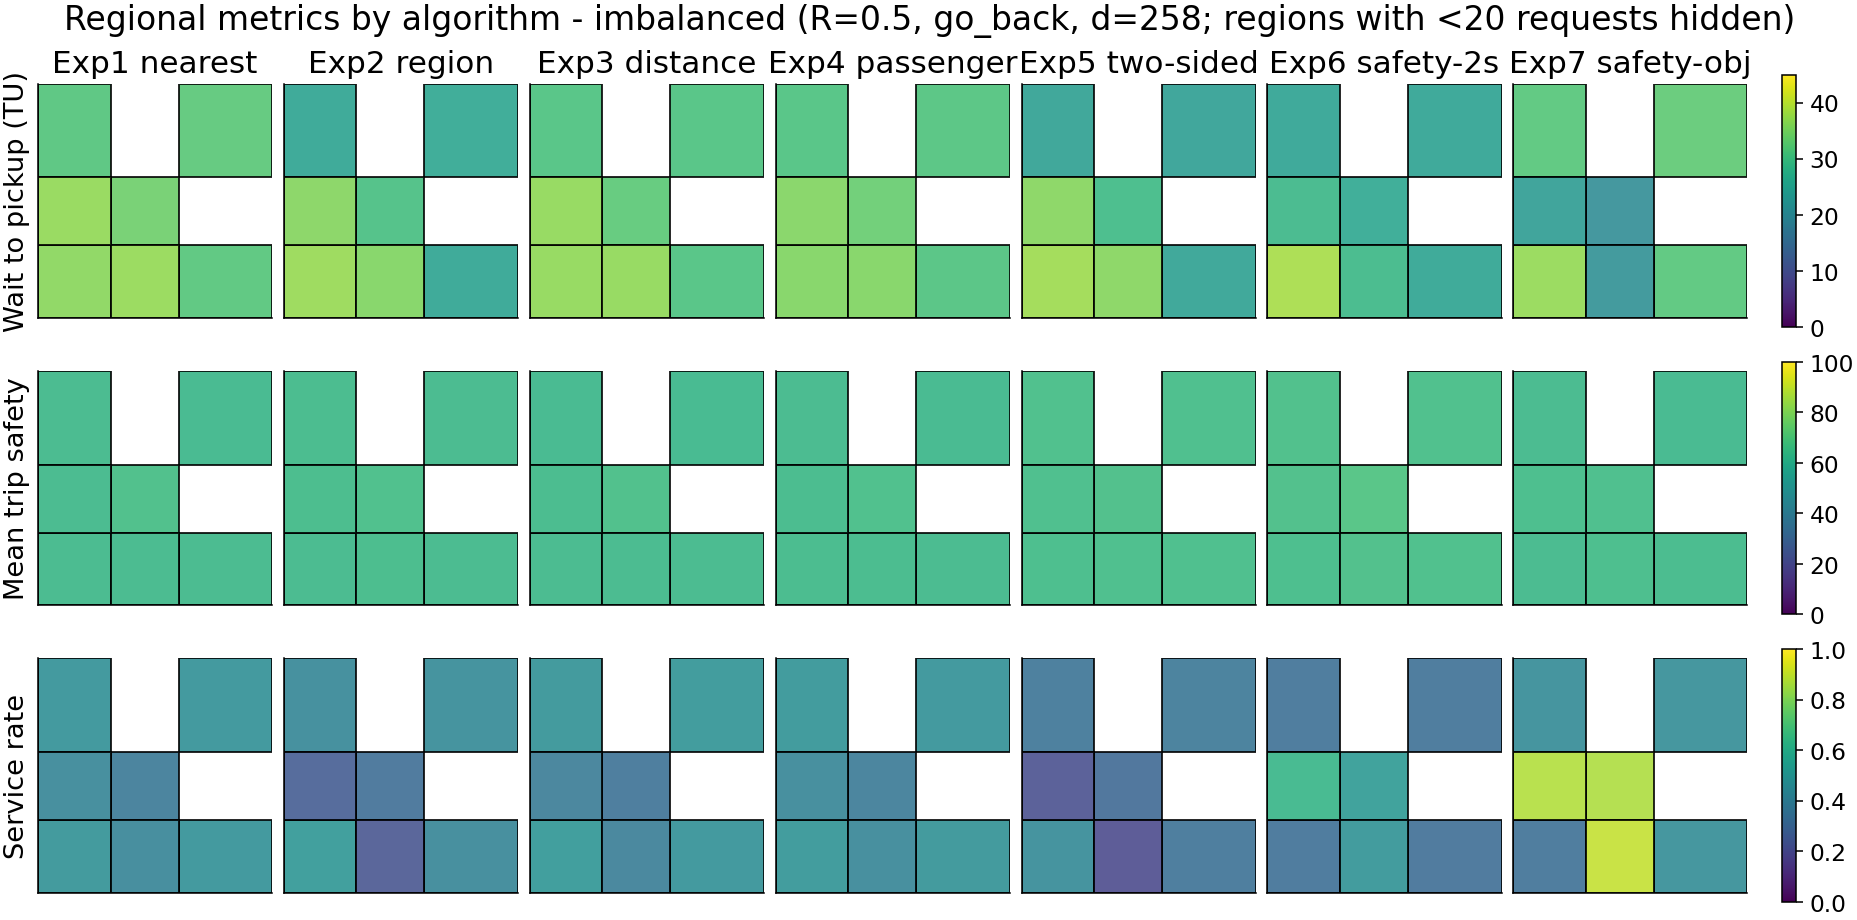

In [6]:
def _enough(stats):
    # Hide near-zero-demand regions so they don't render as gray "NA" boxes.
    return stats[stats['count'] >= MIN_REQUESTS] if 'count' in stats.columns else stats


# Spatial pattern grid: the three metrics down the rows, algorithms across the
# columns. Laid out landscape (was a tall 7-row strip) so the figure sits at the
# text width without being taller than the page. The maps are colour-only -
# position identifies the region and the shared per-metric colorbar gives the
# scale; in-cell labels are dropped because the imbalanced regions are uneven and
# the text collides. Exact per-region values are in the regional tables. All seven
# algorithms are compared here and quantitatively in the regional-Gini figure.
HEATMAP_EXPS = FOUND

# Pre-filter low-demand regions once per algorithm.
hm = {}
n_hidden = 0
for e in HEATMAP_EXPS:
    _row, _req, rcfg, stats = runs[e]
    n_before = len(stats)
    stats = _enough(stats)
    n_hidden += n_before - len(stats)
    hm[e] = (rcfg, stats)

nrow = len(REG_METRICS)
ncol = len(HEATMAP_EXPS)
fig, axes = plt.subplots(nrow, ncol, figsize=(1.9 * ncol, 2.2 * nrow),
                         constrained_layout=True)
axes = np.array(axes).reshape(nrow, ncol)
# Colour anchored to each metric's natural full range (METRIC_RANGE) so a given
# colour means the same absolute value in every panel. One shared colorbar per
# metric row.
for r, (mcol, _src, mlabel, cmap, _hib) in enumerate(REG_METRICS):
    vmin, vmax = METRIC_RANGE.get(mcol, (None, None))
    for c, e in enumerate(HEATMAP_EXPS):
        ax = axes[r, c]
        rcfg, stats = hm[e]
        title = exp_label(e) if r == 0 else ''
        if mcol in stats.columns:
            plot_region_heatmap(ax, stats, mcol, rcfg, title=title,
                                cmap=cmap, vmin=vmin, vmax=vmax,
                                show_labels=False, colorbar=False, square=True)
        else:
            ax.set_title(title)
            ax.axis('off')
        if c == 0:
            ax.set_ylabel(mlabel)
    cb_min, cb_max = METRIC_RANGE.get(mcol, (0.0, 1.0))
    sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap), norm=plt.Normalize(cb_min, cb_max))
    sm.set_array([])
    fig.colorbar(sm, ax=list(axes[r, :]), location='right',
                 fraction=0.046, pad=0.02, aspect=18)
title = (f'Regional metrics by algorithm - {GEOMETRY} '
         f'(R={TARGET_R}, {TARGET_BEHAVIOUR}, d={TARGET_D}')
if n_hidden:
    title += f'; regions with <{MIN_REQUESTS} requests hidden'
title += ')'
fig.suptitle(title)
plt.show()

## 3. Regional Gini

Gini of the per-region means for each metric: how spatially (in)equitable each
algorithm is. Higher = more unequal across regions.

In [ ]:
# Regional Gini averaged over the full sweep, read from the request-regional
# significance cache (region_<fam>_req_gini per run). Same basis as the regional
# significance tables (sweep averages), so the bars and the tables report identical
# numbers. Run-to-run variability behind these levels is quantified by the replicate
# significance test, not shown here.
from exp_utils import load_region_req_metrics_set

GINI_COL = {
    'Wait to pickup (TU)': 'region_wait_req_gini',
    'Mean trip safety': 'region_safety_req_gini',
    'Service rate': 'region_service_req_gini',
}
_sweep = load_region_req_metrics_set(GEOMETRY, cache_dir=CACHE_DIR,
                                     experiments=EXPERIMENTS, include_reps=False)
_sweep_gini = _sweep.groupby('experiment')[list(GINI_COL.values())].mean()

gini_rows = []
for e in FOUND:
    row = {'algorithm': EXP_LABEL[e]}
    if e in _sweep_gini.index:
        for mlabel, gcol in GINI_COL.items():
            row[mlabel] = float(_sweep_gini.loc[e, gcol])
    gini_rows.append(row)
gini_df = pd.DataFrame(gini_rows).set_index('algorithm')

metric_labels = [m[2] for m in REG_METRICS if m[2] in gini_df.columns]
# One panel per metric, stacked vertically and sharing the algorithm axis, so each
# bar chart gets the full panel width and the labels stay legible (the previous
# single-axis grouped layout squeezed three bars per algorithm and shrank the
# text). Portrait aspect because the thesis places the balanced/imbalanced pair
# side-by-side at half text width - a tall narrow figure fills that column and
# renders larger than a landscape one. Each metric keeps its own y-scale.
n = len(metric_labels)
_cmap = plt.get_cmap('tab10')
fig, axes = plt.subplots(n, 1, figsize=(6.5, 3.0 * n), sharex=True)
axes = np.atleast_1d(axes)
x = np.arange(len(FOUND))
for k, (ax, ml) in enumerate(zip(axes, metric_labels)):
    ax.bar(x, gini_df[ml].values, 0.65, color=_cmap(k))
    ax.set_title(ml, fontsize=15)
    ax.set_ylabel('regional Gini', fontsize=13)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([EXP_LABEL[e] for e in FOUND], rotation=35, ha='right',
                         fontsize=13)
fig.suptitle(f'Spatial inequality by algorithm - {GEOMETRY} (sweep average)', fontsize=15)
plt.tight_layout()
plt.show()
display(fmt_display(gini_df.reset_index(),
                    fmt={ml: '{:.3f}' for ml in metric_labels}))


## 4. Non-completion reason by region

For each algorithm, the composition of **non-completed** requests by origin region.
A request that was actively **dropped** (patience expired with no match) is categorised
by its `cancellation_reason` (`no_taxi_available`, `driver_declined`, `passenger_declined`).
Requests that were still in flight when the run ended (`pending`/`waiting`/`serving`)
were never dropped at all - they are censored by the finite horizon and are pooled
into a single grey `incomplete_at_sim_end` bucket.
Keeping both makes nearest (which drops demand) and the preference algorithms
(which leave demand pending) directly comparable, while still making clear which
share is a real drop versus end-of-run censoring.

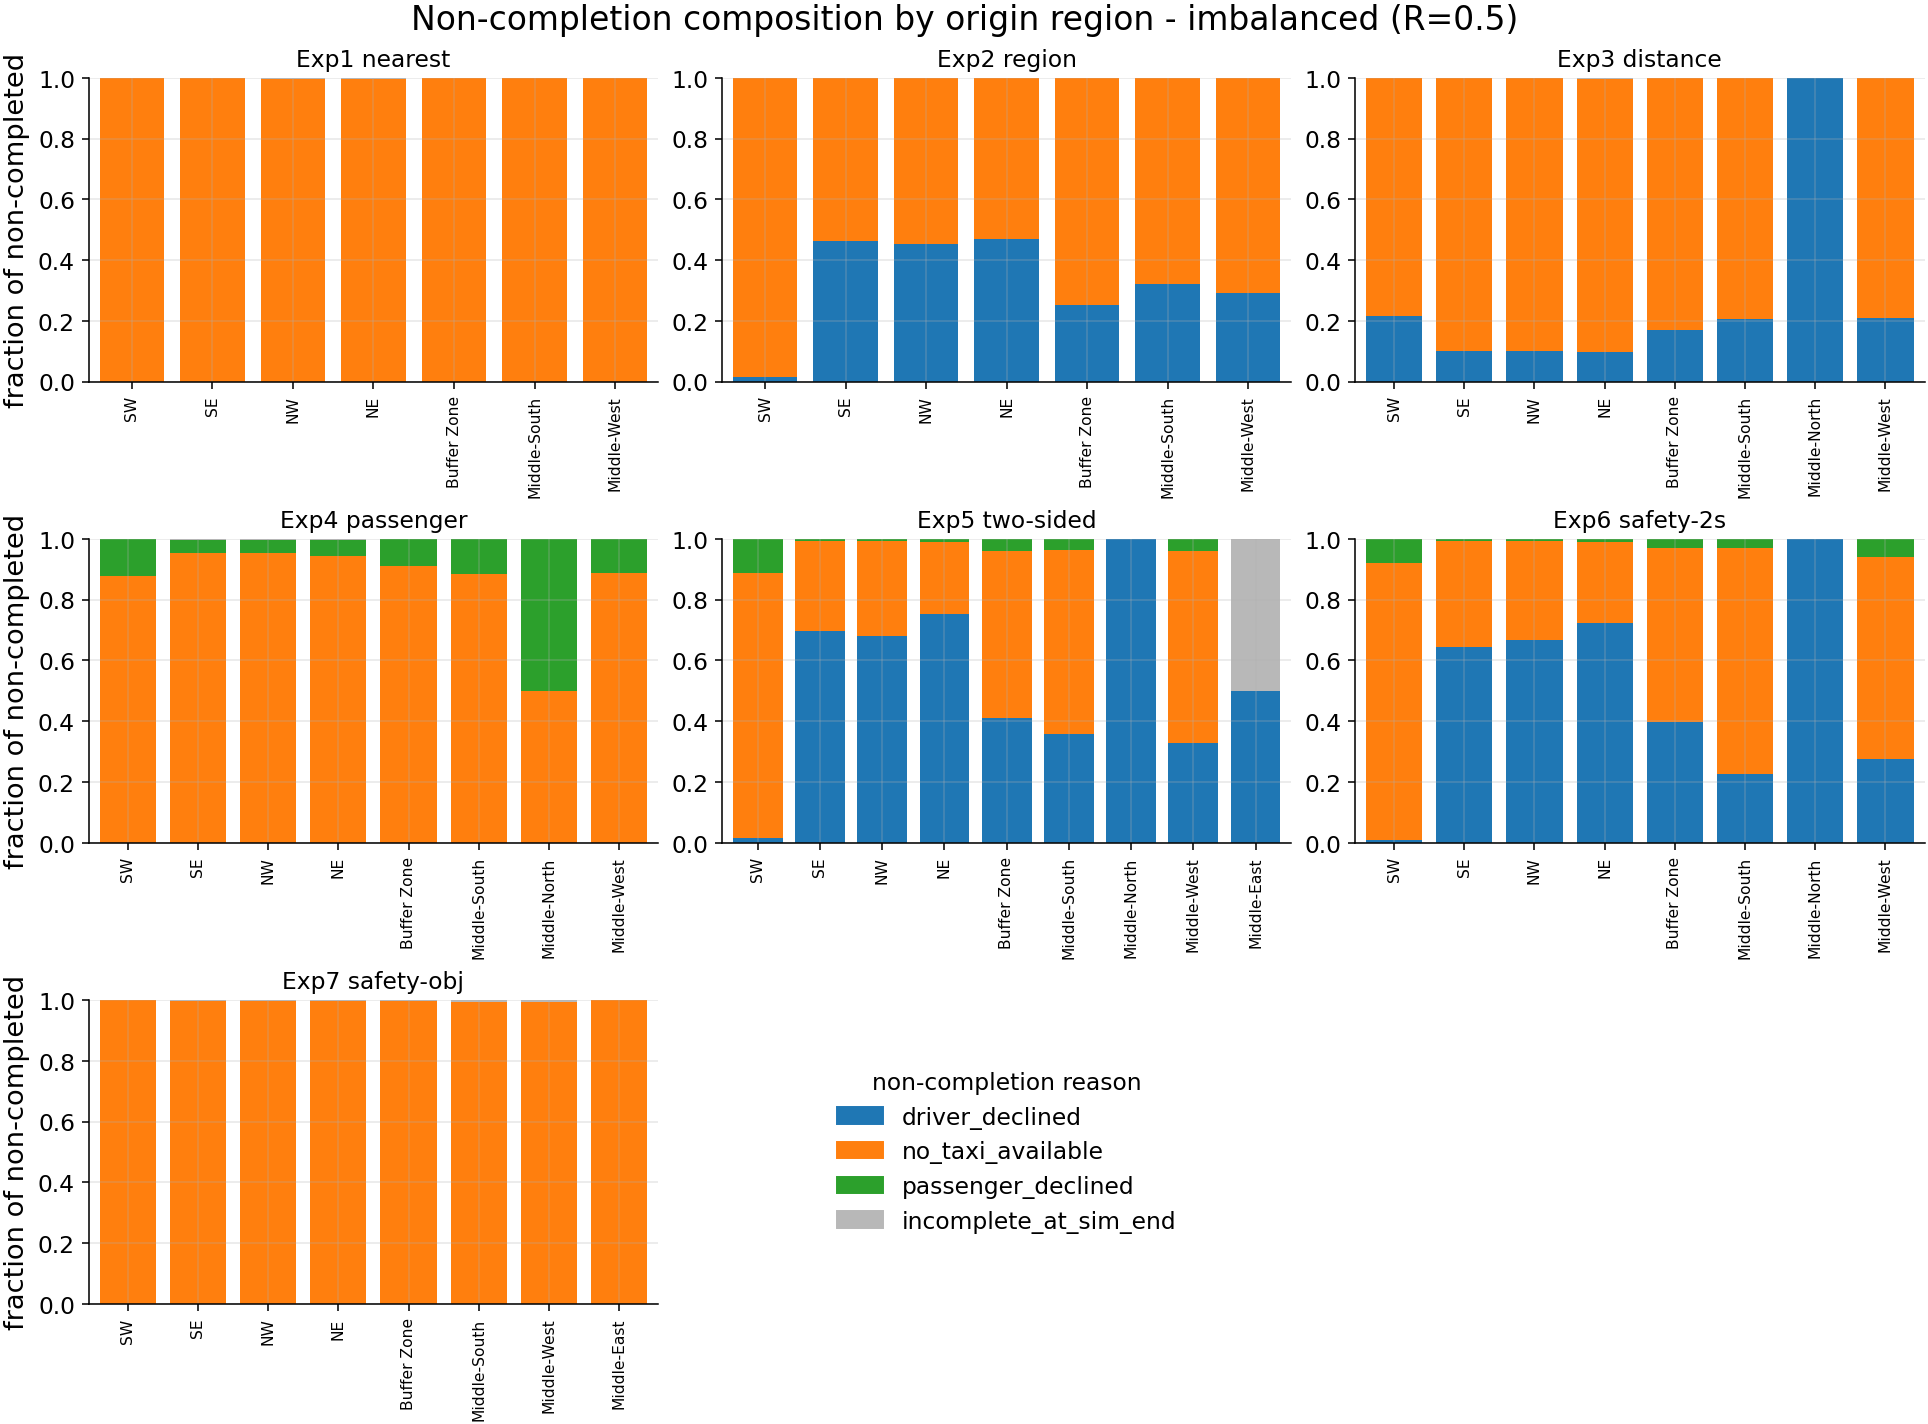

In [8]:
CENSORED = 'incomplete_at_sim_end'   # still pending/waiting/serving at horizon - not a drop


def _short_region(name):
    # Region names like "SW Corner - Main Hub" / "Middle-South Transition" are too
    # long for rotated x-tick labels and squeeze the bars. Drop the descriptive
    # suffix and the "Corner"/"Transition" filler to a compact tag.
    head = name.split(' - ')[0]
    return head.replace(' Transition', '').replace(' Corner', '').strip()


def drop_reason_fractions(req, regions_cfg):
    regions = regions_cfg.get('regions', regions_cfg)
    order = [r['id'] for r in regions]
    names = {r['id']: r['name'] for r in regions}
    nd = req[req['mode'] != 'done'].copy()
    if nd.empty:
        return None, None, None
    is_drop = nd['mode'] == 'dropped'
    # Only dropped requests carry a real drop reason; pending/waiting/serving were
    # in flight when the run ended (censoring), so pool them under one label.
    nd['outcome'] = np.where(
        is_drop,
        nd['cancellation_reason'].fillna('dropped_unknown'),
        CENSORED,
    )
    ct = (nd.groupby(['origin_region', 'outcome']).size().unstack(fill_value=0))
    ct = ct.reindex(order).dropna(how='all')
    frac = ct.div(ct.sum(axis=1), axis=0)
    return frac, [names.get(i, str(i)) for i in frac.index], order


all_reasons = set()
fr_by_exp = {}
for e in FOUND:
    _row, req, rcfg, _stats = runs[e]
    frac, labels, _order = drop_reason_fractions(req, rcfg)
    fr_by_exp[e] = (frac, labels)
    if frac is not None:
        all_reasons.update(frac.columns)
# Real drop reasons keep distinct tab10 colours; the censored bucket is fixed grey
# and drawn last so it reads as visually separate from the actual drops.
drop_reasons = sorted(r for r in all_reasons if r != CENSORED)
rcmap = plt.get_cmap('tab10')
RCOLOR = {r: rcmap(i % 10) for i, r in enumerate(drop_reasons)}
RCOLOR[CENSORED] = (0.72, 0.72, 0.72, 1.0)
plot_order = drop_reasons + ([CENSORED] if CENSORED in all_reasons else [])

ncol = min(3, len(FOUND))
nrow = int(np.ceil(len(FOUND) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.4 * nrow), squeeze=False,
                         constrained_layout=True)
axes = axes.reshape(-1)
for j, (ax, e) in enumerate(zip(axes, FOUND)):
    frac, labels = fr_by_exp[e]
    if frac is None:
        ax.set_title(f'{e}: all completed')
        ax.axis('off')
        continue
    bottom = np.zeros(len(frac))
    xpos = np.arange(len(frac))
    for reason in plot_order:
        if reason in frac.columns:
            ax.bar(xpos, frac[reason].values, bottom=bottom,
                   color=RCOLOR[reason], label=reason)
            bottom += frac[reason].values
    ax.set_xticks(xpos)
    ax.set_xticklabels([_short_region(l) for l in labels], rotation=90, fontsize=8)
    ax.set_ylim(0, 1)
    if j % ncol == 0:
        ax.set_ylabel('fraction of non-completed')
    ax.set_title(EXP_LABEL[e], fontsize=12)

# Trailing empty cells (7 algorithms in a 3-wide grid leaves two) host the legend
# instead of stealing height from the bars with an outside legend.
empty = list(axes[len(FOUND):])
handles = [plt.Rectangle((0, 0), 1, 1, color=RCOLOR[r]) for r in plot_order]
if empty:
    leg_ax = empty[0]
    leg_ax.axis('off')
    leg_ax.legend(handles, plot_order, loc='center', frameon=False,
                  title='non-completion reason', fontsize=12, title_fontsize=12)
    for ax in empty[1:]:
        ax.axis('off')
else:
    fig.legend(handles, plot_order, loc='lower center',
               ncol=len(plot_order), frameon=False)
fig.suptitle(f'Non-completion composition by origin region - {GEOMETRY} (R={TARGET_R})')
plt.show()